In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
import os

# --- CONFIGURATION ---
INPUT_FILE = "outputs/stage1_retrain_visuals/Stage1_Forecast_EXP_CO2_FORCED.csv" 
# ^ If this path is wrong, change it to where your csv is.
OUTPUT_DIR = "outputs/final_visuals"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- STYLE SETTINGS (The "Netflix Documentary" Look) ---
plt.style.use('dark_background')
colors = {'sst': '#FF4B4B', 'par': '#FFD700', 'co2': '#00FFFF', 'text': '#E0E0E0'}

def polish_graph():
    print("--- Generating Hollywood-Grade Visuals ---")
    
    if not os.path.exists(INPUT_FILE):
        print(f"Error: Could not find {INPUT_FILE}")
        return

    df = pd.read_csv(INPUT_FILE)
    df['time'] = pd.to_datetime(df['time'])
    
    # -------------------------------------------------------
    # PLOT 1: The "Danger Zone" (SST with Thresholds)
    # -------------------------------------------------------
    fig, ax = plt.subplots(figsize=(16, 8))
    
    # Background Gradient for "Bleaching Risk" (>29°C)
    ax.axhspan(29, 35, color='red', alpha=0.15, label='Bleaching Risk Zone')
    
    # The Data (Glowing Effect)
    # We plot it twice: once thick/transparent for glow, once thin/opaque for line
    ax.plot(df['time'], df['sst_mean'], color=colors['sst'], linewidth=4, alpha=0.2)
    ax.plot(df['time'], df['sst_mean'], color=colors['sst'], linewidth=1.5, label='Sea Surface Temp (Mean)')
    
    # The Envelope (Min/Max)
    ax.fill_between(df['time'], df['sst_min'], df['sst_max'], color=colors['sst'], alpha=0.1)
    
    # Annotations
    max_temp = df['sst_max'].max()
    max_date = df.loc[df['sst_max'].idxmax(), 'time']
    ax.annotate(f'PEAK HEAT: {max_temp:.1f}°C', xy=(max_date, max_temp), 
                xytext=(max_date, max_temp+1), arrowprops=dict(facecolor='white', shrink=0.05),
                color='white', fontweight='bold')

    # Styling
    ax.set_title("GBR THERMAL PROJECTION (2026-2035)", fontsize=20, fontweight='bold', color='white', pad=20)
    ax.set_ylabel("Temperature (°C)", fontsize=14, color=colors['text'])
    ax.grid(True, color='#333333', linestyle='--', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Save
    plt.savefig(os.path.join(OUTPUT_DIR, "1_Thermal_Danger_Zone_4K.png"), dpi=300, bbox_inches='tight')
    print("-> Saved Plot 1: Thermal Danger Zone")

    # -------------------------------------------------------
    # PLOT 2: The "Driver" (Temp vs CO2)
    # -------------------------------------------------------
    fig, ax1 = plt.subplots(figsize=(16, 8))
    
    # Axis 1: Temp
    ax1.plot(df['time'], df['sst_mean'], color=colors['sst'], linewidth=2)
    ax1.set_ylabel("Ocean Temp (°C)", color=colors['sst'], fontsize=14, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor=colors['sst'])
    
    # Axis 2: CO2
    ax2 = ax1.twinx()
    # If CO2 column exists (it should), plot it
    if 'co2_ppm' in df.columns:
        ax2.plot(df['time'], df['co2_ppm'], color=colors['co2'], linewidth=3, linestyle='--')
        ax2.set_ylabel("Atmospheric CO2 (ppm)", color=colors['co2'], fontsize=14, fontweight='bold')
        ax2.tick_params(axis='y', labelcolor=colors['co2'])
        
        # Add "The Gap" annotation
        start_co2 = df['co2_ppm'].iloc[0]
        end_co2 = df['co2_ppm'].iloc[-1]
        ax2.text(df['time'].iloc[-1], end_co2, f'+{end_co2-start_co2:.0f} ppm', 
                 color=colors['co2'], fontweight='bold', fontsize=12, ha='left')

    ax1.set_title("THE CLIMATE DISCONNECT: RISING CO2 vs. OSCILLATING OCEAN", fontsize=20, fontweight='bold', color='white', pad=20)
    ax1.grid(False) # Clean look
    
    plt.savefig(os.path.join(OUTPUT_DIR, "2_Climate_Driver_4K.png"), dpi=300, bbox_inches='tight')
    print("-> Saved Plot 2: Climate Driver")

if __name__ == "__main__":
    polish_graph()

In [11]:
import pandas as pd
import numpy as np
import plotly.io as pio

df = pd.read_csv(r"C:\Users\tejsr\Downloads\BlueEco_Project\outputs\Stage 2 final\Final_Universal_Forecast.csv")
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').reset_index(drop=True)
df['year'] = df['time'].dt.year
df['month_num'] = df['time'].dt.month

# Southern Hemisphere / GBR seasonal calendar
df['season'] = df['month_num'].map({
    12: 'Austral Summer',
     1: 'Austral Summer',
     2: 'Austral Late Summer',
     3: 'Austral Late Summer',
     4: 'Austral Autumn',
     5: 'Austral Autumn',
     6: 'Austral Winter',
     7: 'Austral Winter',
     8: 'Austral Winter',
     9: 'Austral Spring',
    10: 'Austral Spring',
    11: 'Austral Spring',
})

# Core BlueEco metabolic squeeze parameter
df['metabolic_ratio'] = df['bio_demand'] / df['bio_supply']

# IEEE Plotly theme
pio.templates["ieee"] = pio.templates["simple_white"]
pio.templates["ieee"].layout.update(
    font=dict(family="Times New Roman", size=11, color="black"),
    title_font=dict(family="Times New Roman", size=13),
    legend=dict(font=dict(family="Times New Roman", size=10)),
    paper_bgcolor="white",
    plot_bgcolor="white",
    margin=dict(l=60, r=30, t=80, b=60),
)
pio.templates.default = "ieee"

print(df.shape)
print(df[['time','season','metabolic_ratio','bleaching_risk']].head(12))

(120, 26)
                      time               season  metabolic_ratio  \
0  2026-02-28 00:45:01.884  Austral Late Summer         0.678553   
1  2026-03-31 00:45:01.884  Austral Late Summer         0.694796   
2  2026-04-30 00:45:01.884       Austral Autumn         0.607525   
3  2026-05-31 00:45:01.884       Austral Autumn         0.605161   
4  2026-06-30 00:45:01.884       Austral Winter         0.593855   
5  2026-07-31 00:45:01.884       Austral Winter         0.625188   
6  2026-08-31 00:45:01.884       Austral Winter         0.639934   
7  2026-09-30 00:45:01.884       Austral Spring         0.747051   
8  2026-10-31 00:45:01.884       Austral Spring         0.824335   
9  2026-11-30 00:45:01.884       Austral Spring         0.880785   
10 2026-12-31 00:45:01.884       Austral Summer         0.869025   
11 2027-01-31 00:45:01.884       Austral Summer         0.788648   

    bleaching_risk  
0                0  
1                0  
2                0  
3                0  


In [3]:
import plotly.io as pio

pio.templates["ieee"] = pio.templates["simple_white"]
pio.templates["ieee"].layout.update(
    font=dict(family="Times New Roman", size=11, color="black"),
    title_font=dict(family="Times New Roman", size=13),
    legend=dict(font=dict(family="Times New Roman", size=10)),
    paper_bgcolor="white",
    plot_bgcolor="white",
    margin=dict(l=60, r=30, t=60, b=60),
)
pio.templates.default = "ieee"

# For saving high-res static images (optional, needs kaleido)
# %pip install kaleido
# To save any fig as 300 DPI PNG:
# fig.write_image("figure_name.png", width=1400, height=800, scale=3)

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
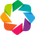

:Chord   [source,target]   (value)

In [12]:
import holoviews as hv
from holoviews import opts
hv.extension('bokeh')

cols = ['sst_mean', 'par_mean', 'kd_490_mean', 'co2_ppm',
        'pred_chlor_a_mean', 'pred_poc_mean', 'bio_demand', 'bio_supply']

labels = ['SST', 'PAR', 'Kd(490)', 'CO₂', 'Chl-a', 'POC', 'Bio Demand', 'Bio Supply']

corr = df[cols].corr()
corr.index = labels
corr.columns = labels

links = []
for i, src in enumerate(labels):
    for j, tgt in enumerate(labels):
        if i < j:
            val = corr.loc[src, tgt]
            if abs(val) > 0.3:
                links.append((src, tgt, abs(val) * 100))

links_df = pd.DataFrame(links, columns=['source', 'target', 'value'])

chord = hv.Chord(links_df).opts(
    opts.Chord(
        width=650, height=650,
        title='Chord Diagram: Variable Relationships — GBR Forecast (|r| > 0.3)',
        labels='index',
        node_color='index',
        edge_color='source',
        cmap='Category20',
        edge_alpha=0.6,
        label_text_font_size='10pt',
    )
)

hv.save(chord, 'fig1_chord_diagram.html')
chord

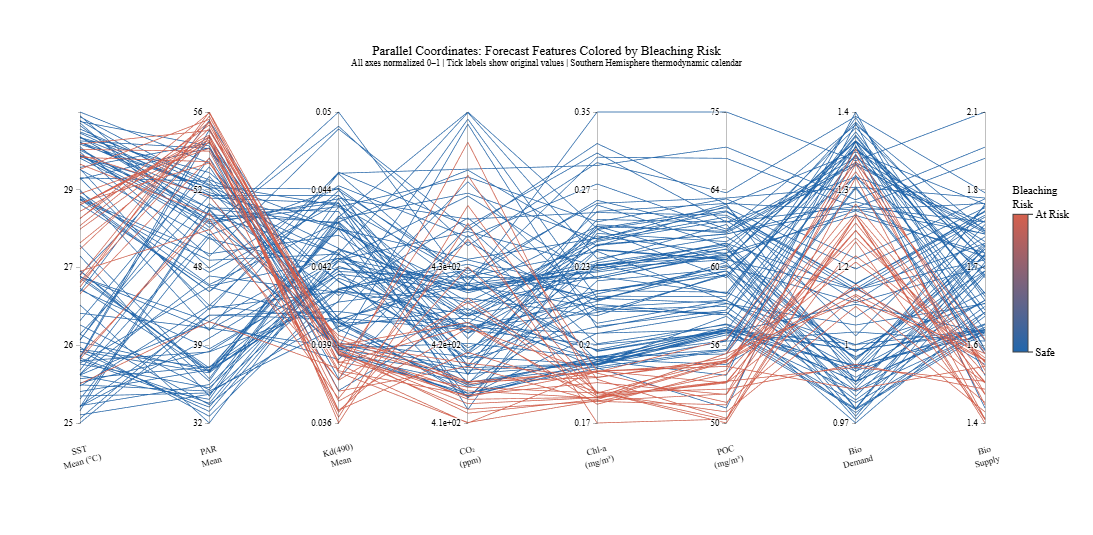

In [13]:
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler

features = ['sst_mean', 'par_mean', 'kd_490_mean', 'co2_ppm',
            'pred_chlor_a_mean', 'pred_poc_mean', 'bio_demand', 'bio_supply']

nice_labels = {
    'sst_mean':          'SST<br>Mean (°C)',
    'par_mean':          'PAR<br>Mean',
    'kd_490_mean':       'Kd(490)<br>Mean',
    'co2_ppm':           'CO₂<br>(ppm)',
    'pred_chlor_a_mean': 'Chl-a<br>(mg/m³)',
    'pred_poc_mean':     'POC<br>(mg/m³)',
    'bio_demand':        'Bio<br>Demand',
    'bio_supply':        'Bio<br>Supply',
}

scaler = MinMaxScaler()
scaled = pd.DataFrame(
    scaler.fit_transform(df[features]),
    columns=features
)
scaled['bleaching_risk'] = df['bleaching_risk'].values

dimensions = []
for col in features:
    orig = df[col]
    dimensions.append(dict(
        label=nice_labels[col],
        values=scaled[col],
        tickvals=[0, 0.25, 0.5, 0.75, 1.0],
        ticktext=[
            f"{orig.min():.2g}",
            f"{orig.quantile(0.25):.2g}",
            f"{orig.median():.2g}",
            f"{orig.quantile(0.75):.2g}",
            f"{orig.max():.2g}",
        ],
    ))

fig = go.Figure(go.Parcoords(
    line=dict(
        color=scaled['bleaching_risk'],
        colorscale=[[0, '#2166ac'], [1, '#d6604d']],
        showscale=True,
        cmin=0, cmax=1,
        colorbar=dict(
            title=dict(text='Bleaching<br>Risk', font=dict(size=11)),
            tickvals=[0, 1],
            ticktext=['Safe', 'At Risk'],
            len=0.6,
            thickness=15,
            x=1.02,
        )
    ),
    dimensions=dimensions,
    labelside='bottom',
    labelangle=-15,
))

fig.update_layout(
    title=dict(
        text='Parallel Coordinates: Forecast Features Colored by Bleaching Risk<br>'
             '<sup>All axes normalized 0–1 | Tick labels show original values | '
             'Southern Hemisphere thermodynamic calendar</sup>',
        x=0.5, xanchor='center',
        font=dict(family='Times New Roman', size=13),
    ),
    font=dict(family='Times New Roman', size=11),
    paper_bgcolor='white',
    height=520,
    width=1100,
    margin=dict(l=80, r=100, t=110, b=110),
)

fig.write_html('fig2_parallel_coordinates.html')
# fig.write_image('fig2_parallel_coordinates.png', width=1400, height=600, scale=3)
fig.show()

In [14]:
import networkx as nx
from pyvis.network import Network

cols = ['sst_mean', 'par_mean', 'kd_490_mean', 'co2_ppm',
        'pred_chlor_a_mean', 'pred_poc_mean', 'bio_demand', 'bio_supply']

labels = {
    'sst_mean':          'SST',
    'par_mean':          'PAR',
    'kd_490_mean':       'Kd(490)',
    'co2_ppm':           'CO₂',
    'pred_chlor_a_mean': 'Chl-a',
    'pred_poc_mean':     'POC',
    'bio_demand':        'Bio Demand',
    'bio_supply':        'Bio Supply',
}

corr = df[cols].corr()

G = nx.Graph()
for col in cols:
    G.add_node(labels[col])

THRESHOLD = 0.4
for i, c1 in enumerate(cols):
    for j, c2 in enumerate(cols):
        if i < j:
            r = corr.loc[c1, c2]
            if abs(r) > THRESHOLD:
                G.add_edge(
                    labels[c1], labels[c2],
                    weight=round(abs(r), 2),
                    title=f"r = {r:.2f}",
                    color='#d73027' if r < 0 else '#1a9850',
                    width=int(abs(r) * 10)
                )

net = Network(
    height='650px', width='100%', notebook=True,
    bgcolor='#ffffff', font_color='#222222',
    heading='Network Graph: GBR Variable Correlations (|r| > 0.4)'
)

net.from_nx(G)

for node in net.nodes:
    node['size'] = 28
    node['font'] = {'size': 14, 'face': 'Times New Roman'}
    node['color'] = '#4575b4'

net.set_options("""
var options = {
  "physics": {
    "forceAtlas2Based": {
      "gravitationalConstant": -80,
      "centralGravity": 0.01,
      "springLength": 150
    },
    "solver": "forceAtlas2Based"
  }
}
""")

net.show('fig3_network_graph.html')

fig3_network_graph.html


In [3]:
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler

stream_vars = {
    'sst_mean':          'SST Mean',
    'par_mean':          'PAR Mean',
    'pred_chlor_a_mean': 'Chl-a',
    'pred_poc_mean':     'POC',
    'bio_demand':        'Bio Demand',
    'bio_supply':        'Bio Supply',
}

scaler = MinMaxScaler()
scaled = pd.DataFrame(
    scaler.fit_transform(df[list(stream_vars.keys())]),
    columns=list(stream_vars.keys())
)
scaled['time'] = df['time'].values

colors = ['#4393c3', '#f4a582', '#92c5de', '#d6604d', '#74add1', '#a6d96a']

fig = go.Figure()
for (col, label), color in zip(stream_vars.items(), colors):
    fig.add_trace(go.Scatter(
        x=scaled['time'],
        y=scaled[col],
        name=label,
        mode='lines',
        line=dict(width=0.5, color=color),
        stackgroup='one',
        fillcolor=color,
        opacity=0.75,
        hovertemplate=f'<b>{label}</b><br>Date: %{{x|%Y-%m}}<br>Normalized Value: %{{y:.2f}}<extra></extra>'
    ))

# Mark bleaching risk windows
bleach_months = df[df['bleaching_risk'] == 1]['time']
for t in bleach_months:
    fig.add_vrect(
        x0=t - pd.DateOffset(days=15),
        x1=t + pd.DateOffset(days=15),
        fillcolor='rgba(214,96,77,0.12)',
        line_width=0,
    )

fig.update_layout(
    title=dict(
        text='Streamgraph: Temporal Evolution of GBR Forecast Variables (2026–2036)<br>'
             '<sup>Normalized 0–1 | Red shading = Bleaching Risk periods (Austral Late Summer/Autumn)</sup>',
        x=0.5, xanchor='center',
        font=dict(family='Times New Roman', size=13),
    ),
    xaxis_title='Date (Austral Calendar)',
    yaxis_title='Normalized Value (stacked)',
    font=dict(family='Times New Roman', size=11),
    legend=dict(orientation='h', y=-0.18, x=0.5, xanchor='center'),
    hovermode='x unified',
    height=500,
    width=1100,
    paper_bgcolor='white',
    plot_bgcolor='#fafafa',
    margin=dict(l=70, r=40, t=100, b=100),
)

# fig.write_html('fig4_streamgraph.html')
# # fig.write_image('fig4_streamgraph.png', width=1400, height=600, scale=3)
# To this:
fig.write_image('fig10_sst_anomaly_heatmap.png', width=1200, height=550, scale=3)
fig.show()



NameError: name 'pd' is not defined

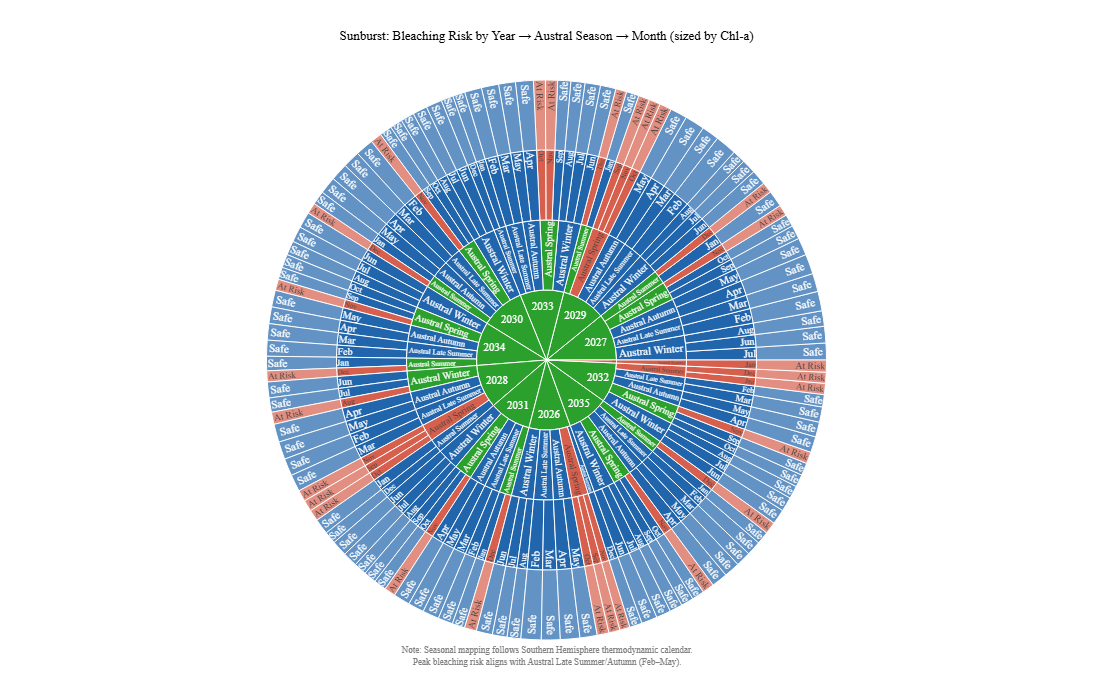

In [16]:
import plotly.express as px

sunburst_df = df[['year', 'season', 'month_num', 'bleaching_risk', 'pred_chlor_a_mean']].copy()
sunburst_df['bleach_label'] = sunburst_df['bleaching_risk'].map({0: 'Safe', 1: 'At Risk'})
sunburst_df['month_name'] = pd.to_datetime(sunburst_df['month_num'], format='%m').dt.strftime('%b')
sunburst_df['year_str'] = sunburst_df['year'].astype(str)

agg = sunburst_df.groupby(
    ['year_str', 'season', 'month_name', 'bleach_label'], as_index=False
).agg(
    chl_a=('pred_chlor_a_mean', 'mean'),
    count=('bleaching_risk', 'count')
)

fig = px.sunburst(
    agg,
    path=['year_str', 'season', 'month_name', 'bleach_label'],
    values='chl_a',
    color='bleach_label',
    color_discrete_map={
        'Safe':    '#2166ac',
        'At Risk': '#d6604d',
    },
    title='Sunburst: Bleaching Risk by Year → Austral Season → Month (sized by Chl-a)',
    branchvalues='total',
    hover_data={'chl_a': ':.3f'},
)

fig.update_layout(
    font=dict(family='Times New Roman', size=11),
    title=dict(
        x=0.5, xanchor='center',
        font=dict(family='Times New Roman', size=13),
    ),
    height=680,
    margin=dict(t=80, l=0, r=0, b=40),
    annotations=[dict(
        text='Note: Seasonal mapping follows Southern Hemisphere thermodynamic calendar.<br>'
             'Peak bleaching risk aligns with Austral Late Summer/Autumn (Feb–May).',
        x=0.5, y=-0.05, xref='paper', yref='paper',
        showarrow=False,
        font=dict(family='Times New Roman', size=9, color='grey'),
        align='center',
    )]
)

fig.write_html('fig5_sunburst.html')
# fig.write_image('fig5_sunburst.png', width=1200, height=800, scale=3)
fig.show()

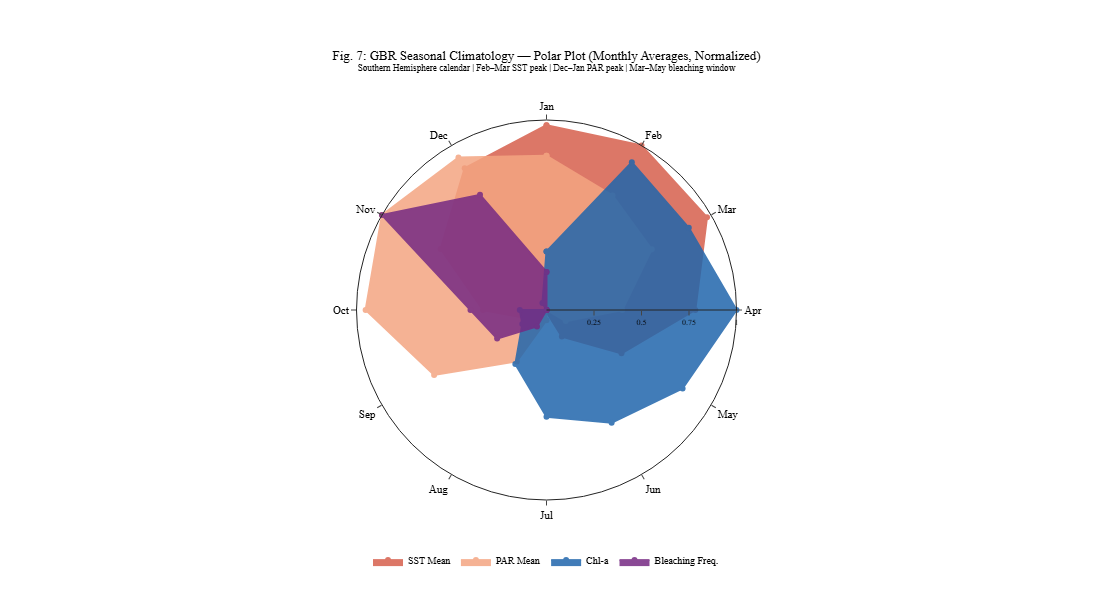

In [17]:
import plotly.graph_objects as go
import numpy as np

monthly_avg = df.groupby('month').agg(
    sst=('sst_mean', 'mean'),
    par=('par_mean', 'mean'),
    chl=('pred_chlor_a_mean', 'mean'),
    bleach=('bleaching_risk', 'mean')
).reset_index()

# Normalize each variable to 0–1 for radar
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
norm = pd.DataFrame(
    scaler.fit_transform(monthly_avg[['sst', 'par', 'chl', 'bleach']]),
    columns=['SST Mean', 'PAR Mean', 'Chl-a', 'Bleaching Freq.']
)
norm['month'] = monthly_avg['month']

month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

fig = go.Figure()

colors = {
    'SST Mean':      '#d6604d',
    'PAR Mean':      '#f4a582',
    'Chl-a':         '#2166ac',
    'Bleaching Freq.':'#762a83'
}

for col, color in colors.items():
    vals = norm[col].tolist()
    vals += [vals[0]]  # close the loop
    fig.add_trace(go.Scatterpolar(
        r=vals,
        theta=month_labels + [month_labels[0]],
        name=col,
        line=dict(color=color, width=2),
        fill='toself',
        fillcolor=color.replace(')', ',0.08)').replace('rgb', 'rgba') if 'rgb' in color else color,
        opacity=0.85,
    ))

fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True, range=[0, 1],
            tickvals=[0.25, 0.5, 0.75, 1.0],
            tickfont=dict(size=8, family='Times New Roman'),
            gridcolor='lightgrey',
        ),
        angularaxis=dict(
            tickfont=dict(size=11, family='Times New Roman'),
            direction='clockwise',
            rotation=90,
        ),
        bgcolor='white',
    ),
    title=dict(
        text='Fig. 7: GBR Seasonal Climatology — Polar Plot (Monthly Averages, Normalized)<br>'
             '<sup>Southern Hemisphere calendar | Feb–Mar SST peak | Dec–Jan PAR peak | Mar–May bleaching window</sup>',
        x=0.5, xanchor='center',
        font=dict(family='Times New Roman', size=13),
    ),
    legend=dict(
        font=dict(family='Times New Roman', size=10),
        orientation='h', y=-0.12, x=0.5, xanchor='center'
    ),
    paper_bgcolor='white',
    height=600, width=700,
    margin=dict(t=120, b=100, l=80, r=80),
)

fig.write_html('fig7_polar_climatology.html')
# fig.write_image('fig7_polar_climatology.png', width=900, height=750, scale=3)
fig.show()

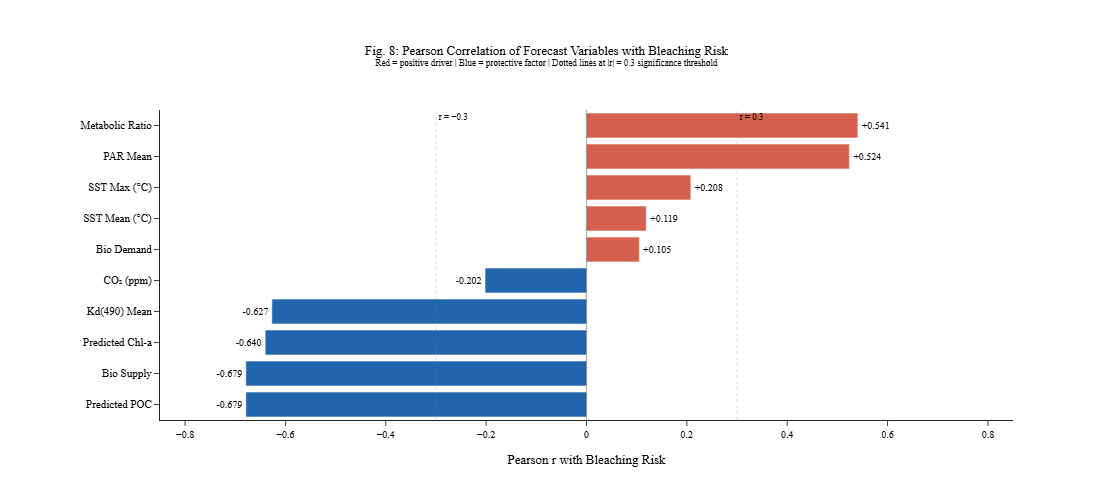

In [18]:
import plotly.graph_objects as go

cols = ['sst_mean', 'sst_max', 'par_mean', 'kd_490_mean', 'co2_ppm',
        'pred_chlor_a_mean', 'pred_poc_mean', 'bio_demand', 'bio_supply', 'metabolic_ratio']

nice = {
    'sst_mean':          'SST Mean (°C)',
    'sst_max':           'SST Max (°C)',
    'par_mean':          'PAR Mean',
    'kd_490_mean':       'Kd(490) Mean',
    'co2_ppm':           'CO₂ (ppm)',
    'pred_chlor_a_mean': 'Predicted Chl-a',
    'pred_poc_mean':     'Predicted POC',
    'bio_demand':        'Bio Demand',
    'bio_supply':        'Bio Supply',
    'metabolic_ratio':   'Metabolic Ratio',
}

corrs = df[cols].corrwith(df['bleaching_risk']).rename(nice).sort_values()

colors = ['#d6604d' if v > 0 else '#2166ac' for v in corrs.values]

fig = go.Figure(go.Bar(
    x=corrs.values,
    y=corrs.index,
    orientation='h',
    marker=dict(color=colors, line=dict(width=0.5, color='white')),
    text=[f'{v:+.3f}' for v in corrs.values],
    textposition='outside',
    textfont=dict(family='Times New Roman', size=10),
    hovertemplate='%{y}<br>r = %{x:.3f}<extra></extra>',
))

fig.add_vline(x=0, line_width=1.2, line_color='black')
fig.add_vline(x=0.3,  line_dash='dot', line_color='grey', line_width=1,
              annotation_text='r = 0.3', annotation_font=dict(size=9))
fig.add_vline(x=-0.3, line_dash='dot', line_color='grey', line_width=1,
              annotation_text='r = −0.3', annotation_font=dict(size=9))

fig.update_layout(
    title=dict(
        text='Fig. 8: Pearson Correlation of Forecast Variables with Bleaching Risk<br>'
             '<sup>Red = positive driver | Blue = protective factor | Dotted lines at |r| = 0.3 significance threshold</sup>',
        x=0.5, xanchor='center',
        font=dict(family='Times New Roman', size=13),
    ),
    xaxis=dict(
        title='Pearson r with Bleaching Risk',
        range=[-0.85, 0.85],
        tickfont=dict(family='Times New Roman', size=10),
        gridcolor='#eeeeee',
    ),
    yaxis=dict(tickfont=dict(family='Times New Roman', size=11)),
    paper_bgcolor='white',
    plot_bgcolor='white',
    height=480, width=800,
    margin=dict(l=160, r=80, t=110, b=60),
    showlegend=False,
)

fig.write_html('fig8_correlation_bar.html')
# fig.write_image('fig8_correlation_bar.png', width=1000, height=600, scale=3)
fig.show()

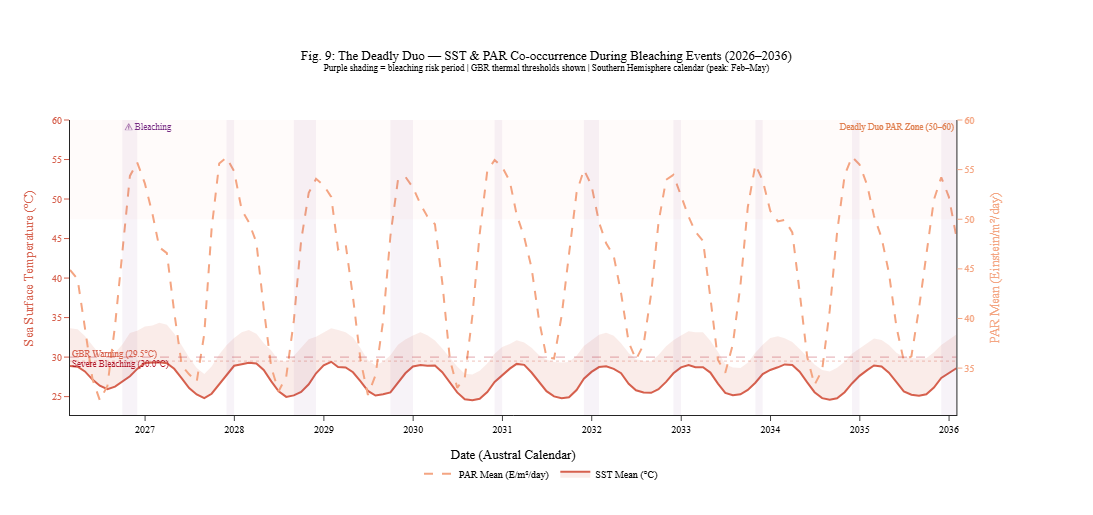

In [19]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(specs=[[{"secondary_y": True}]])

# SST Mean + Max band
fig.add_trace(go.Scatter(
    x=df['time'], y=df['sst_max'],
    name='SST Max (°C)',
    line=dict(color='rgba(214,96,77,0.3)', width=0),
    fill=None, showlegend=False,
), secondary_y=False)

fig.add_trace(go.Scatter(
    x=df['time'], y=df['sst_mean'],
    name='SST Mean (°C)',
    line=dict(color='#d6604d', width=2),
    fill='tonexty',
    fillcolor='rgba(214,96,77,0.12)',
), secondary_y=False)

# GBR thermal stress thresholds
fig.add_hline(y=29.5, line_dash='dot', line_color='#d6604d',
              line_width=1.2, secondary_y=False,
              annotation_text='GBR Warning (29.5°C)',
              annotation_font=dict(size=9, color='#d6604d'),
              annotation_position='top left')

fig.add_hline(y=30.0, line_dash='dash', line_color='#b2182b',
              line_width=1.2, secondary_y=False,
              annotation_text='Severe Bleaching (30.0°C)',
              annotation_font=dict(size=9, color='#b2182b'),
              annotation_position='bottom left')

# PAR on secondary axis
fig.add_trace(go.Scatter(
    x=df['time'], y=df['par_mean'],
    name='PAR Mean (E/m²/day)',
    line=dict(color='#f4a582', width=2, dash='dash'),
), secondary_y=True)

# PAR deadly threshold band
fig.add_hrect(y0=50, y1=60, secondary_y=True,
              fillcolor='rgba(244,165,130,0.15)', line_width=0,
              annotation_text='Deadly Duo PAR Zone (50–60)',
              annotation_font=dict(size=9, color='#e08050'),
              annotation_position='top right')

# Bleaching risk shading
death_df = df[df['bleaching_risk'] == 1].copy()
groups = (death_df.index.to_series().diff() != 1).cumsum()
first = True
for _, grp in death_df.groupby(groups):
    fig.add_vrect(
        x0=grp['time'].iloc[0], x1=grp['time'].iloc[-1],
        fillcolor='rgba(118,42,131,0.18)', line_width=0,
        annotation_text='⚠ Bleaching' if first else '',
        annotation_font=dict(size=9, color='#762a83'),
        annotation_position='top left',
    )
    first = False

fig.update_layout(
    title=dict(
        text='Fig. 9: The Deadly Duo — SST & PAR Co-occurrence During Bleaching Events (2026–2036)<br>'
             '<sup>Purple shading = bleaching risk period | GBR thermal thresholds shown | '
             'Southern Hemisphere calendar (peak: Feb–May)</sup>',
        x=0.5, xanchor='center',
        font=dict(family='Times New Roman', size=13),
    ),
    xaxis=dict(title='Date (Austral Calendar)',
               tickfont=dict(family='Times New Roman', size=10)),
    yaxis=dict(title='Sea Surface Temperature (°C)',
               tickfont=dict(family='Times New Roman', size=10),
               color='#d6604d'),
    yaxis2=dict(title='PAR Mean (Einstein/m²/day)',
                tickfont=dict(family='Times New Roman', size=10),
                color='#f4a582'),
    legend=dict(orientation='h', y=-0.15, x=0.5, xanchor='center',
                font=dict(family='Times New Roman', size=10)),
    paper_bgcolor='white',
    plot_bgcolor='white',
    height=500, width=1100,
    margin=dict(l=70, r=80, t=120, b=100),
)

fig.write_html('fig9_deadly_duo.html')
# fig.write_image('fig9_deadly_duo.png', width=1400, height=600, scale=3)
fig.show()

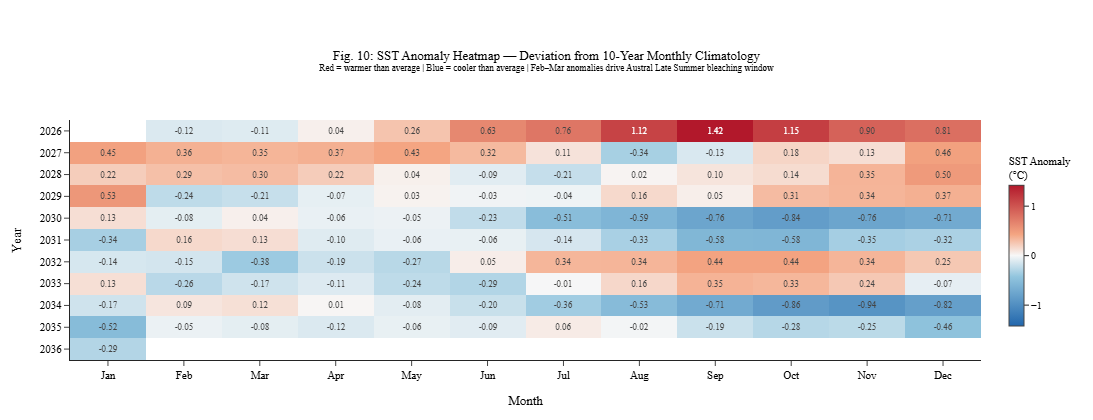

In [21]:
import plotly.express as px
import numpy as np

df['year'] = df['time'].dt.year

# Climatological mean per month across all years
monthly_clim = df.groupby('month')['sst_mean'].mean()
df['sst_anomaly'] = df['sst_mean'] - df['month'].map(monthly_clim)

# Build pivot — keep year as integer index, month as integer columns
pivot = df.pivot_table(index='year', columns='month', values='sst_anomaly', aggfunc='mean')
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                 'Jul','Aug','Sep','Oct','Nov','Dec']
pivot.index = pivot.index.astype(str)  # convert year to string AFTER pivot

fig = px.imshow(
    pivot,
    color_continuous_scale=[
        [0.0,  '#2166ac'],
        [0.35, '#92c5de'],
        [0.5,  '#f7f7f7'],
        [0.65, '#f4a582'],
        [1.0,  '#b2182b'],
    ],
    color_continuous_midpoint=0,
    text_auto='.2f',
    aspect='auto',
    labels=dict(x='Month', y='Year', color='SST Anomaly (°C)'),
)

fig.update_traces(
    textfont=dict(family='Times New Roman', size=9),
)

fig.update_layout(
    title=dict(
        text='Fig. 10: SST Anomaly Heatmap — Deviation from 10-Year Monthly Climatology<br>'
             '<sup>Red = warmer than average | Blue = cooler than average | '
             'Feb–Mar anomalies drive Austral Late Summer bleaching window</sup>',
        x=0.5, xanchor='center',
        font=dict(family='Times New Roman', size=13),
    ),
    xaxis=dict(title='Month', tickfont=dict(family='Times New Roman', size=11)),
    yaxis=dict(title='Year',  tickfont=dict(family='Times New Roman', size=11)),
    coloraxis_colorbar=dict(
        title=dict(text='SST Anomaly<br>(°C)', font=dict(family='Times New Roman', size=11)),
        tickfont=dict(family='Times New Roman', size=10),
        thickness=15, len=0.8,
    ),
    paper_bgcolor='white',
    height=420, width=950,
    margin=dict(l=70, r=40, t=120, b=60),
)

fig.write_html('fig10_sst_anomaly_heatmap.html')
# fig.write_image('fig10_sst_anomaly_heatmap.png', width=1200, height=550, scale=3)
fig.show()

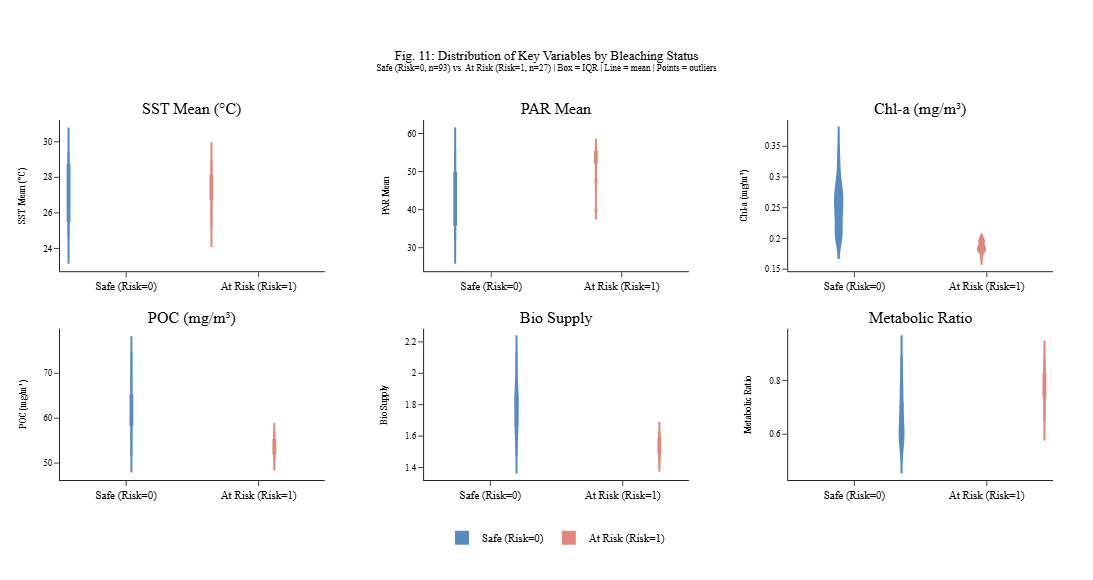

In [22]:
import plotly.graph_objects as go

variables = {
    'sst_mean':          'SST Mean (°C)',
    'par_mean':          'PAR Mean',
    'pred_chlor_a_mean': 'Chl-a (mg/m³)',
    'pred_poc_mean':     'POC (mg/m³)',
    'bio_supply':        'Bio Supply',
    'metabolic_ratio':   'Metabolic Ratio',
}

from plotly.subplots import make_subplots
fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=list(variables.values()),
    vertical_spacing=0.16,
    horizontal_spacing=0.10,
)

positions = [(1,1),(1,2),(1,3),(2,1),(2,2),(2,3)]
safe_color   = '#2166ac'
risk_color   = '#d6604d'

for (col, label), (row, c) in zip(variables.items(), positions):
    for risk_val, name, color in [(0,'Safe (Risk=0)', safe_color),
                                   (1,'At Risk (Risk=1)', risk_color)]:
        subset = df[df['bleaching_risk'] == risk_val][col]
        fig.add_trace(go.Violin(
            y=subset,
            name=name,
            legendgroup=name,
            showlegend=(row == 1 and c == 1),
            line_color=color,
            fillcolor=color.replace('#', 'rgba(').replace(')', ',0.2)') if False else color,
            opacity=0.75,
            box_visible=True,
            meanline_visible=True,
            points='outliers',
            pointpos=0,
            marker=dict(size=4, opacity=0.5),
            hovertemplate=f'{label}<br>{name}<br>Value: %{{y:.3f}}<extra></extra>',
        ), row=row, col=c)

    fig.update_yaxes(
        title_text=label,
        title_font=dict(size=9, family='Times New Roman'),
        tickfont=dict(size=9, family='Times New Roman'),
        row=row, col=c
    )

fig.update_layout(
    title=dict(
        text='Fig. 11: Distribution of Key Variables by Bleaching Status<br>'
             '<sup>Safe (Risk=0, n=93) vs. At Risk (Risk=1, n=27) | '
             'Box = IQR | Line = mean | Points = outliers</sup>',
        x=0.5, xanchor='center',
        font=dict(family='Times New Roman', size=13),
    ),
    violingap=0.05,
    violinmode='group',
    legend=dict(
        orientation='h', y=-0.12, x=0.5, xanchor='center',
        font=dict(family='Times New Roman', size=11),
    ),
    paper_bgcolor='white',
    plot_bgcolor='white',
    height=580, width=1050,
    margin=dict(l=60, r=40, t=120, b=100),
)

fig.write_html('fig11_violin_plots.html')
# fig.write_image('fig11_violin_plots.png', width=1400, height=700, scale=3)
fig.show()

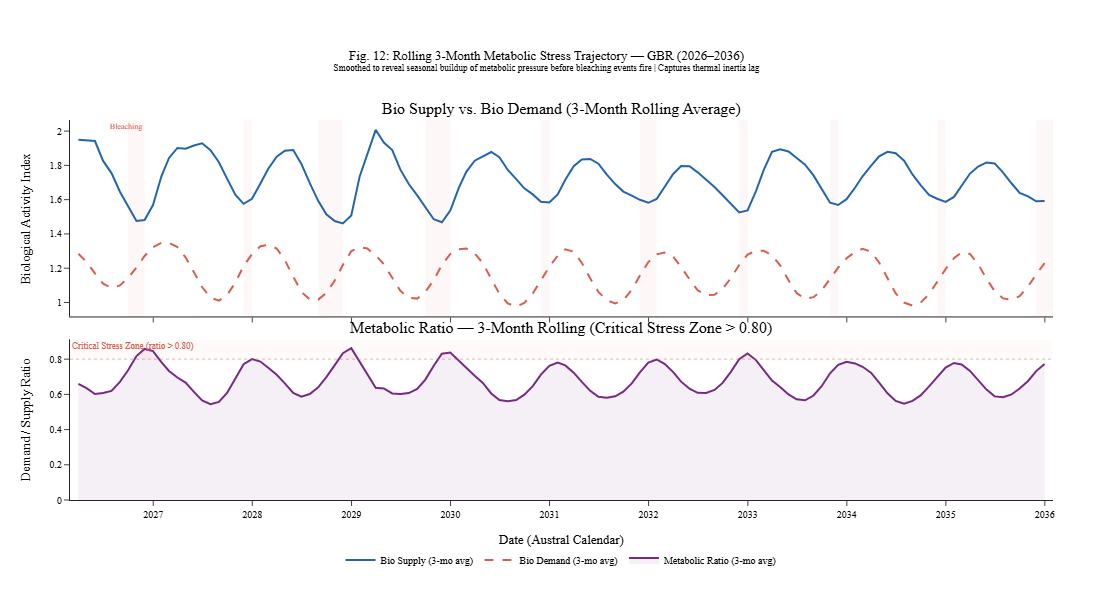

In [23]:
import plotly.graph_objects as go

df['metabolic_ratio'] = df['bio_demand'] / df['bio_supply']
df['ratio_rolling']   = df['metabolic_ratio'].rolling(3, center=True).mean()
df['supply_rolling']  = df['bio_supply'].rolling(3, center=True).mean()
df['demand_rolling']  = df['bio_demand'].rolling(3, center=True).mean()

# Critical stress zone threshold (ratio > 0.80 = approaching tipping point)
STRESS_THRESHOLD = 0.80

fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    row_heights=[0.55, 0.45],
    vertical_spacing=0.06,
    subplot_titles=[
        'Bio Supply vs. Bio Demand (3-Month Rolling Average)',
        'Metabolic Ratio — 3-Month Rolling (Critical Stress Zone > 0.80)'
    ]
)

# Panel 1
fig.add_trace(go.Scatter(
    x=df['time'], y=df['supply_rolling'],
    name='Bio Supply (3-mo avg)',
    line=dict(color='#2166ac', width=2),
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=df['time'], y=df['demand_rolling'],
    name='Bio Demand (3-mo avg)',
    line=dict(color='#d6604d', width=2, dash='dash'),
), row=1, col=1)

# Shade bleaching risk windows
death_df = df[df['bleaching_risk'] == 1].copy()
groups = (death_df.index.to_series().diff() != 1).cumsum()
first = True
for _, grp in death_df.groupby(groups):
    fig.add_vrect(
        x0=grp['time'].iloc[0], x1=grp['time'].iloc[-1],
        fillcolor='rgba(214,96,77,0.15)', line_width=0,
        annotation_text='Bleaching' if first else '',
        annotation_font=dict(size=8, color='#d6604d'),
        row=1, col=1
    )
    first = False

# Panel 2: Rolling ratio
fig.add_trace(go.Scatter(
    x=df['time'], y=df['ratio_rolling'],
    name='Metabolic Ratio (3-mo avg)',
    line=dict(color='#762a83', width=2),
    fill='tozeroy',
    fillcolor='rgba(118,42,131,0.07)',
), row=2, col=1)

# Critical stress zone
fig.add_hrect(
    y0=STRESS_THRESHOLD, y1=df['metabolic_ratio'].max() + 0.02,
    fillcolor='rgba(214,96,77,0.10)', line_width=0,
    annotation_text='Critical Stress Zone (ratio > 0.80)',
    annotation_font=dict(size=9, color='#d6604d'),
    annotation_position='top left',
    row=2, col=1
)

fig.add_hline(
    y=STRESS_THRESHOLD, line_dash='dot', line_color='#d6604d',
    line_width=1.5, row=2, col=1,
)

fig.update_layout(
    title=dict(
        text='Fig. 12: Rolling 3-Month Metabolic Stress Trajectory — GBR (2026–2036)<br>'
             '<sup>Smoothed to reveal seasonal buildup of metabolic pressure before bleaching events fire | '
             'Captures thermal inertia lag</sup>',
        x=0.5, xanchor='center',
        font=dict(family='Times New Roman', size=13),
    ),
    legend=dict(orientation='h', y=-0.12, x=0.5, xanchor='center',
                font=dict(family='Times New Roman', size=10)),
    paper_bgcolor='white',
    plot_bgcolor='white',
    height=600, width=1050,
    margin=dict(l=70, r=40, t=120, b=100),
)

fig.update_yaxes(title_text='Biological Activity Index', row=1, col=1,
                 tickfont=dict(family='Times New Roman', size=10))
fig.update_yaxes(title_text='Demand / Supply Ratio', row=2, col=1,
                 tickfont=dict(family='Times New Roman', size=10))
fig.update_xaxes(title_text='Date (Austral Calendar)', row=2, col=1,
                 tickfont=dict(family='Times New Roman', size=10))

fig.write_html('fig12_rolling_metabolic_stress.html')
# fig.write_image('fig12_rolling_metabolic_stress.png', width=1400, height=700, scale=3)
fig.show()

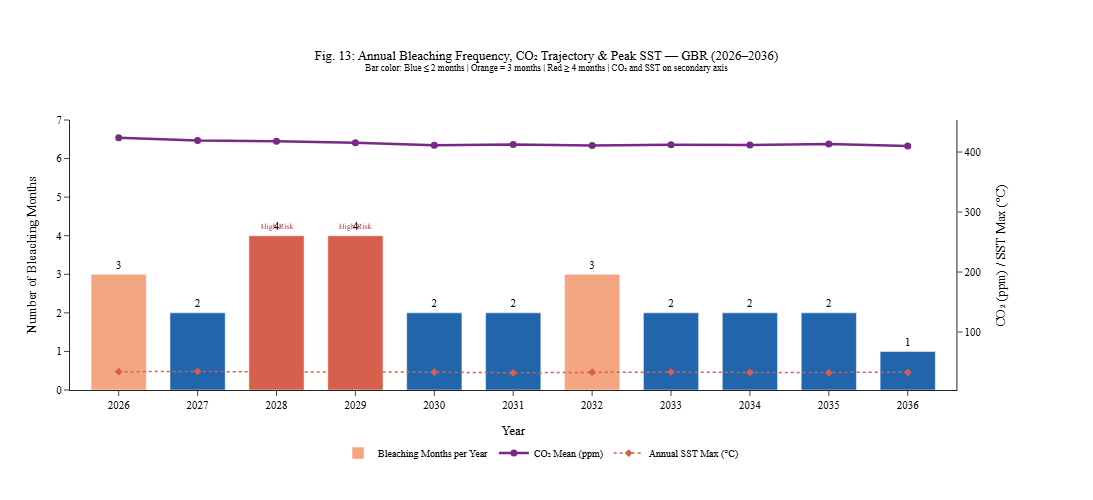

In [24]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

yearly = df.groupby('year').agg(
    bleach_months=('bleaching_risk', 'sum'),
    co2_mean=('co2_ppm', 'mean'),
    sst_max=('sst_max', 'max'),
).reset_index()

# Color bars by bleaching count intensity
bar_colors = [
    '#2166ac' if v <= 2 else '#f4a582' if v <= 3 else '#d6604d'
    for v in yearly['bleach_months']
]

fig = make_subplots(specs=[[{"secondary_y": True}]])

# Bleaching months bar
fig.add_trace(go.Bar(
    x=yearly['year'],
    y=yearly['bleach_months'],
    name='Bleaching Months per Year',
    marker=dict(color=bar_colors, line=dict(color='white', width=0.5)),
    text=yearly['bleach_months'],
    textposition='outside',
    textfont=dict(family='Times New Roman', size=11),
    hovertemplate='Year: %{x}<br>Bleaching Months: %{y}<extra></extra>',
), secondary_y=False)

# CO2 trend line
fig.add_trace(go.Scatter(
    x=yearly['year'],
    y=yearly['co2_mean'],
    name='CO₂ Mean (ppm)',
    line=dict(color='#762a83', width=2.5),
    mode='lines+markers',
    marker=dict(size=7, color='#762a83'),
    hovertemplate='Year: %{x}<br>CO₂: %{y:.1f} ppm<extra></extra>',
), secondary_y=True)

# Annual max SST scatter
fig.add_trace(go.Scatter(
    x=yearly['year'],
    y=yearly['sst_max'],
    name='Annual SST Max (°C)',
    line=dict(color='#d6604d', width=1.5, dash='dot'),
    mode='lines+markers',
    marker=dict(size=6, symbol='diamond', color='#d6604d'),
    hovertemplate='Year: %{x}<br>SST Max: %{y:.2f}°C<extra></extra>',
), secondary_y=True)

# Annotate bleaching risk years
for _, row_data in yearly[yearly['bleach_months'] >= 4].iterrows():
    fig.add_annotation(
        x=row_data['year'],
        y=row_data['bleach_months'] + 0.25,
        text='High Risk',
        showarrow=False,
        font=dict(size=8, color='#b2182b', family='Times New Roman'),
    )

fig.update_layout(
    title=dict(
        text='Fig. 13: Annual Bleaching Frequency, CO₂ Trajectory & Peak SST — GBR (2026–2036)<br>'
             '<sup>Bar color: Blue ≤ 2 months | Orange = 3 months | Red ≥ 4 months | '
             'CO₂ and SST on secondary axis</sup>',
        x=0.5, xanchor='center',
        font=dict(family='Times New Roman', size=13),
    ),
    xaxis=dict(
        title='Year',
        tickmode='linear', tick0=2026, dtick=1,
        tickfont=dict(family='Times New Roman', size=11),
    ),
    yaxis=dict(
        title='Number of Bleaching Months',
        range=[0, 7],
        tickfont=dict(family='Times New Roman', size=11),
        gridcolor='#eeeeee',
    ),
    yaxis2=dict(
        title='CO₂ (ppm) / SST Max (°C)',
        tickfont=dict(family='Times New Roman', size=11),
        showgrid=False,
    ),
    legend=dict(orientation='h', y=-0.18, x=0.5, xanchor='center',
                font=dict(family='Times New Roman', size=10)),
    paper_bgcolor='white',
    plot_bgcolor='white',
    bargap=0.3,
    height=500, width=1000,
    margin=dict(l=70, r=80, t=120, b=110),
)

fig.write_html('fig13_yearly_bleaching_co2.html')
# fig.write_image('fig13_yearly_bleaching_co2.png', width=1300, height=620, scale=3)
fig.show()